# AI-Based Loan Approval and Credit Risk Analysis System

## Proje Amacı

Bu projede makine öğrenmesi kullanılarak bir müşterinin kredi başvurusunun onaylanıp onaylanmayacağı tahmin edilecektir.

Proje kapsamında:

- Veri Ön İşleme (Preprocessing)
- Keşifsel Veri Analizi (EDA)
- Sınıflandırma Modelleri
- Cross Validation
- Performans Metrikleri
- Confusion Matrix
- ROC Eğrisi
- Model Karşılaştırması
- Açıklanabilir Yapay Zeka (XAI)
- Streamlit Web Uygulaması

geliştirilecektir.

In [1]:
# Veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Ön işleme
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Veri bölme ve doğrulama
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Modeller
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrikler
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc

# Uyarıları kapat
import warnings
warnings.filterwarnings("ignore")

## Kütüphanelerin Yüklenmesi

Bu aşamada veri işleme, veri görselleştirme, makine öğrenmesi ve performans değerlendirme işlemlerinde kullanılacak Python kütüphaneleri projeye dahil edilmiştir.

In [2]:
# Load dataset
df = pd.read_csv("../data/loan_data.csv")

# Display first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Veri Setinin Yüklenmesi

Bu aşamada kredi başvuru verileri sisteme yüklenmiştir.

İlk 5 kayıt görüntülenerek veri setinin genel yapısı incelenmiştir.

In [3]:
print("Satır Sayısı :", df.shape[0])
print("Sütun Sayısı :", df.shape[1])

Satır Sayısı : 614
Sütun Sayısı : 13


## Veri Seti Boyutunun İncelenmesi

Veri setindeki toplam gözlem ve değişken sayıları incelenmiştir.

Bu bilgiler veri setinin büyüklüğü hakkında bilgi vermektedir.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Veri Tiplerinin İncelenmesi

Bu aşamada değişkenlerin veri tipleri incelenmiştir.

Makine öğrenmesi modelleri sayısal verilerle çalıştığı için kategorik değişkenlerin dönüştürülmesi gerekecektir.

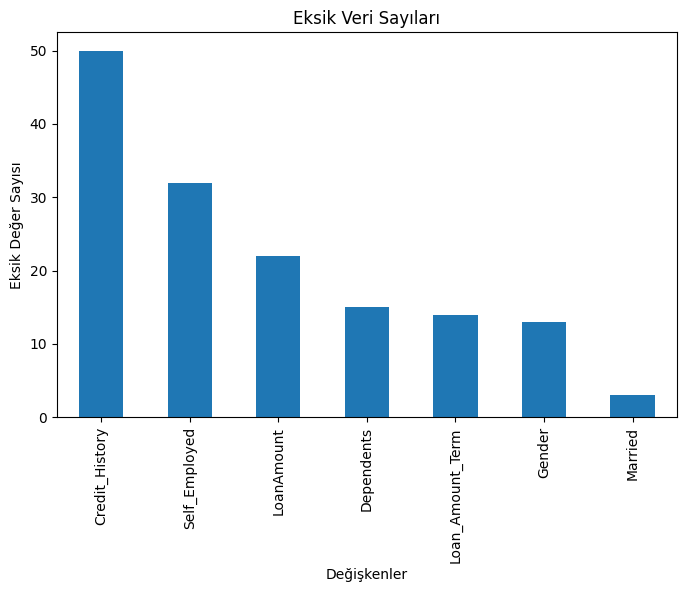

In [5]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Eksik Veri Sayıları")
plt.ylabel("Eksik Değer Sayısı")
plt.xlabel("Değişkenler")
plt.show()

## Eksik Veri Görselleştirmesi

Eksik değerlerin veri setindeki dağılımı görsel olarak incelenmiştir.

Bu sayede hangi sütunlarda eksik verilerin yoğunlaştığı tespit edilmiştir.

In [6]:
# Kategorik değişkenleri mod (en sık görülen değer) ile doldurma

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Sayısal değişkenleri ortalama ile doldurma

df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)

# Kredi süresi ve kredi geçmişi

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

## Eksik Verilerin Doldurulması

Veri setinde bulunan eksik değerler uygun yöntemler kullanılarak doldurulmuştur.

- Kategorik değişkenlerde en sık görülen değer (Mode) kullanılmıştır.
- Sayısal değişkenlerde ortalama değer (Mean) kullanılmıştır.

Bu işlem veri kaybını önlemek ve model performansını artırmak amacıyla yapılmıştır.

In [7]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [8]:
df.drop("Loan_ID", axis=1, inplace=True)

## Gereksiz Değişkenin Kaldırılması

Loan_ID sütunu her başvuru için benzersiz bir kimlik numarası içermektedir.

Bu sütun tahmin işlemi için anlamlı bilgi taşımadığından veri setinden çıkarılmıştır.


In [9]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y


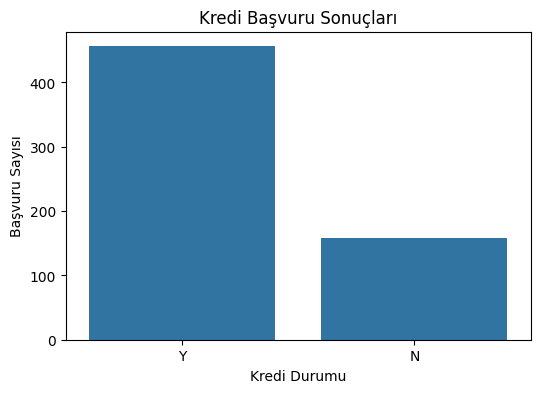

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=df)

plt.title("Kredi Başvuru Sonuçları")
plt.xlabel("Kredi Durumu")
plt.ylabel("Başvuru Sayısı")

plt.show()

## Kredi Başvuru Sonuçlarının İncelenmesi

Bu grafik veri setindeki kredi başvurularının onaylanma ve reddedilme dağılımını göstermektedir.

Bu dağılım hedef değişkenin dengeli olup olmadığını incelemek için kullanılmıştır.

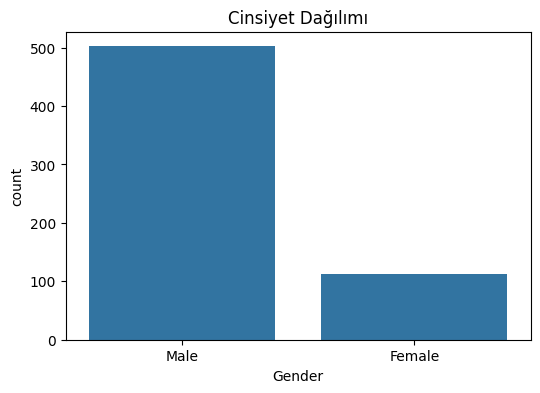

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Cinsiyet Dağılımı")

plt.show()

## Cinsiyet Dağılımı

Bu grafik başvuru sahiplerinin cinsiyet dağılımını göstermektedir.

Veri setindeki demografik yapı hakkında genel bilgi vermektedir.

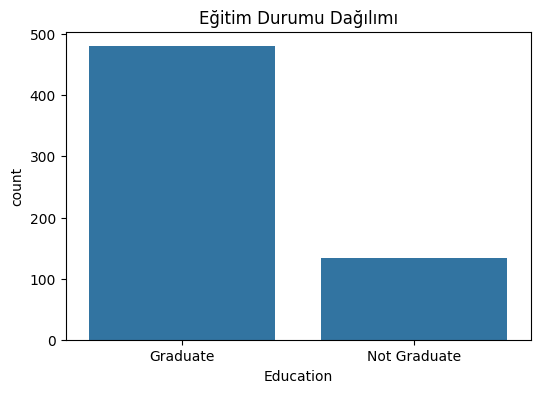

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Education', data=df)

plt.title("Eğitim Durumu Dağılımı")

plt.show()

## Eğitim Durumu Analizi

Başvuru sahiplerinin eğitim seviyeleri incelenmiştir.

Eğitim durumunun kredi onay sürecine etkisi daha sonraki analizlerde değerlendirilecektir.

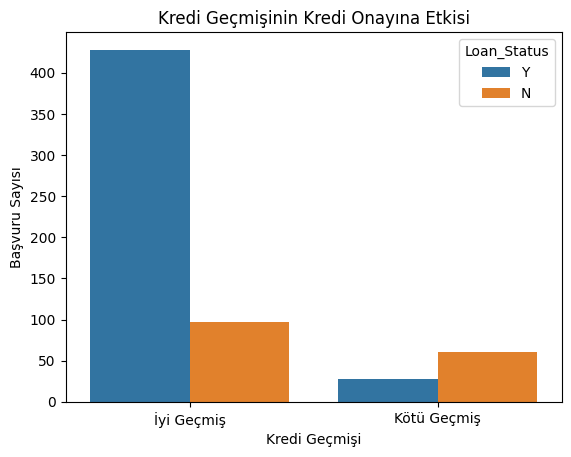

In [13]:
credit_history_labels = {
    0.0: "Kötü Geçmiş",
    1.0: "İyi Geçmiş"
}

temp_df = df.copy()

temp_df["Credit_History"] = temp_df["Credit_History"].map(
    credit_history_labels
)

sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=temp_df
)

plt.title("Kredi Geçmişinin Kredi Onayına Etkisi")
plt.xlabel("Kredi Geçmişi")
plt.ylabel("Başvuru Sayısı")

plt.show()

## Kredi Geçmişinin Etkisi

Bu grafik kredi geçmişi ile kredi onayı arasındaki ilişkiyi göstermektedir.

Kredi geçmişinin kredi onayı üzerinde önemli bir etkisi olup olmadığı incelenmiştir.

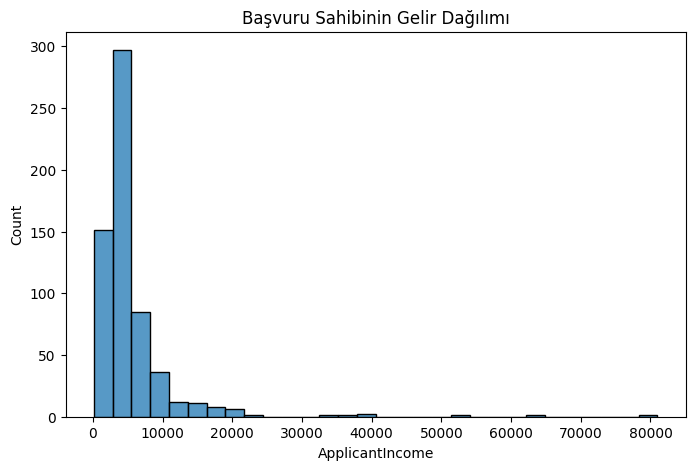

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['ApplicantIncome'], bins=30)

plt.title("Başvuru Sahibinin Gelir Dağılımı")

plt.show()

## Gelir Dağılımı

Başvuru sahiplerinin gelir dağılımı incelenmiştir.

Bu analiz gelir değerlerinin dağılımını ve olası aykırı değerleri gözlemlemek amacıyla yapılmıştır.

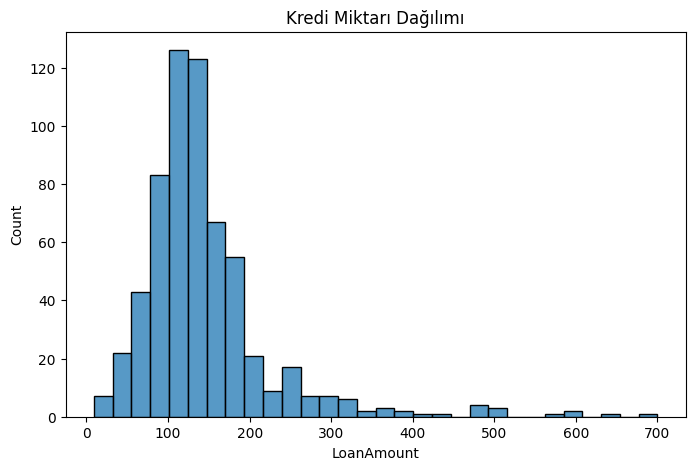

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['LoanAmount'], bins=30)

plt.title("Kredi Miktarı Dağılımı")

plt.show()

## Kredi Miktarı Dağılımı

Talep edilen kredi miktarlarının dağılımı incelenmiştir.

Bu grafik kredi miktarlarının yoğunlaştığı aralıkları göstermektedir.

In [16]:
# Kategorik değişkenleri sayısala dönüştürme

label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

## Kategorik Verilerin Sayısallaştırılması

Makine öğrenmesi algoritmaları metinsel veriler ile çalışamadığı için kategorik değişkenler sayısal değerlere dönüştürülmüştür.

Bu işlem Label Encoding yöntemi kullanılarak gerçekleştirilmiştir.

In [17]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


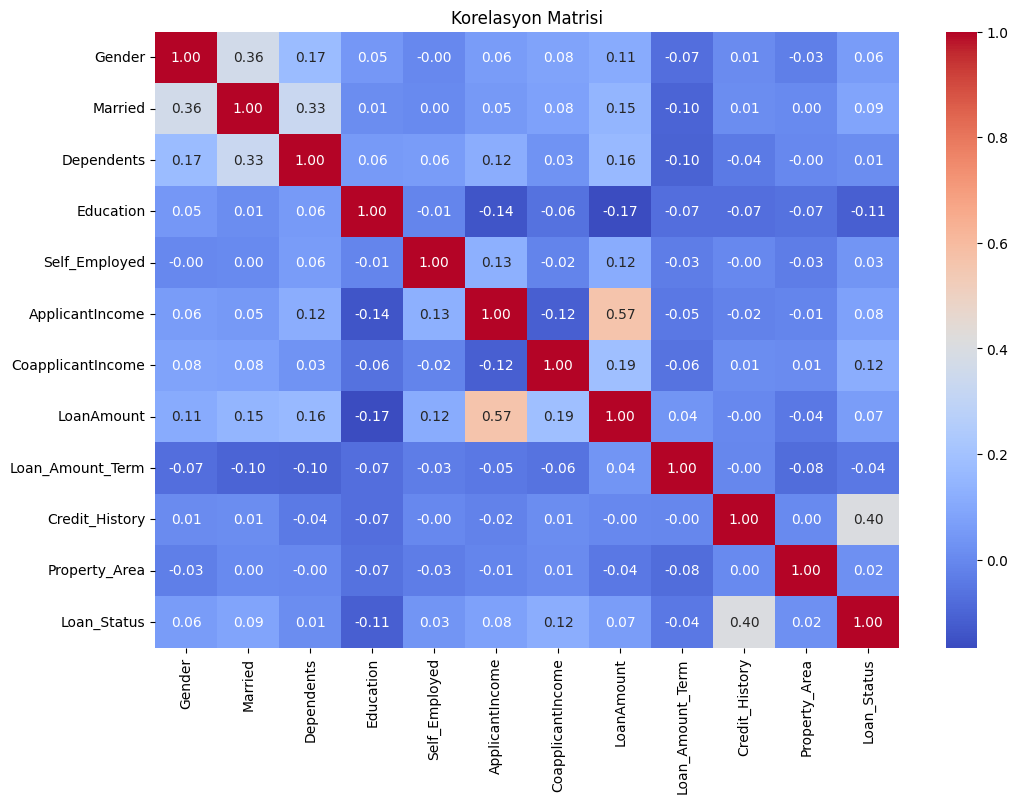

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Korelasyon Matrisi")

plt.show()

## Korelasyon Analizi

Değişkenler arasındaki ilişkiler korelasyon matrisi kullanılarak incelenmiştir.

Özellikle kredi onayı ile güçlü ilişkiye sahip değişkenler belirlenmeye çalışılmıştır.

In [19]:
# Özellikler (X)
X = df.drop("Loan_Status", axis=1)

# Hedef değişken (y)
y = df["Loan_Status"]

## Bağımlı ve Bağımsız Değişkenlerin Belirlenmesi

Bu aşamada hedef değişken (Loan_Status) veri setinden ayrılmıştır.

- X : Modelin kullanacağı özellikler
- y : Tahmin edilmek istenen hedef değişken

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Eğitim ve Test Verilerinin Oluşturulması

Veri seti:

- %80 Eğitim Verisi
- %20 Test Verisi

olarak ikiye ayrılmıştır.

Eğitim verisi modelin öğrenmesi için, test verisi ise performans değerlendirmesi için kullanılmıştır.

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Verilerin Ölçeklendirilmesi

Değişkenlerin farklı büyüklüklerde olması model performansını etkileyebileceği için StandardScaler kullanılarak veriler ölçeklendirilmiştir.


.

In [22]:
lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

.


# Lojistik Regresyon Performansı

In [23]:
lr_metrics = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred)
}

lr_df = pd.DataFrame(
    lr_metrics.items(),
    columns=["Metric", "Score"]
)

lr_df

,Metric,Score
0,Accuracy,0.788618
1,Precision,0.783019
2,Recall,0.965116
3,F1 Score,0.864583


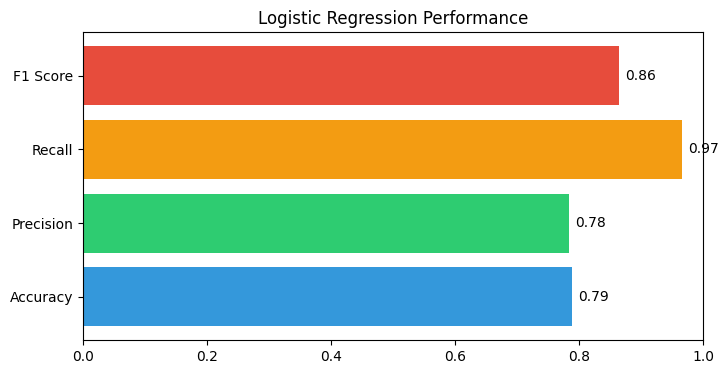

In [24]:
lr_metrics = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred)
}

plt.figure(figsize=(8,4))

colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]

bars = plt.barh(
    list(lr_metrics.keys()),
    list(lr_metrics.values()),
    color=colors
)

plt.xlim(0,1)
plt.title("Logistic Regression Performance")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.show()


.

# Karar Ağacı Performansı

In [25]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [26]:
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 0.7073170731707317
Precision: 0.7659574468085106
Recall   : 0.8372093023255814
F1 Score : 0.8


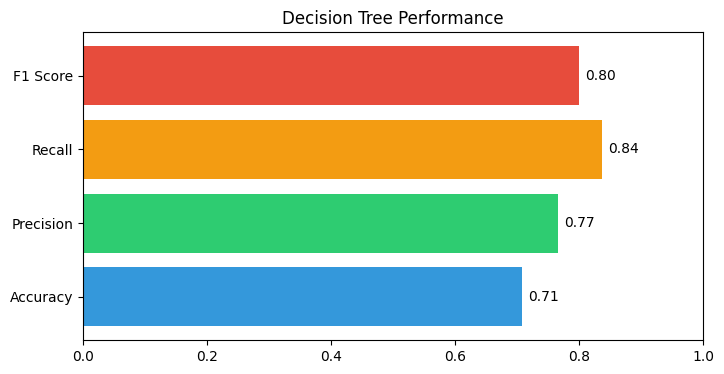

In [27]:
dt_metrics = {
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "F1 Score": f1_score(y_test, dt_pred)
}

plt.figure(figsize=(8,4))

colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]

bars = plt.barh(
    list(dt_metrics.keys()),
    list(dt_metrics.values()),
    color=colors
)

plt.xlim(0,1)
plt.title("Decision Tree Performance")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.show()

.


# Random Forest Performance

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.7642276422764228
Precision: 0.7663551401869159
Recall   : 0.9534883720930233
F1 Score : 0.8497409326424871


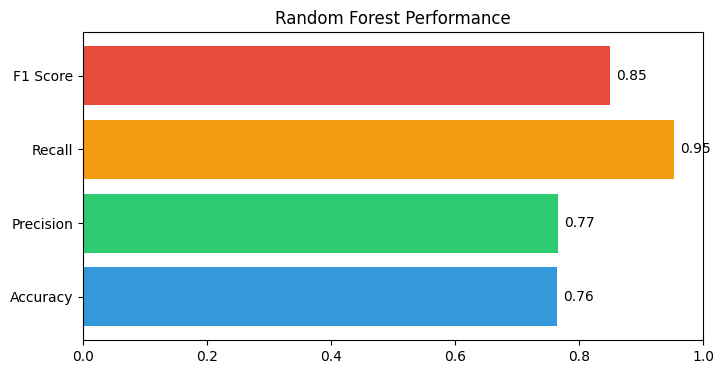

In [29]:
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred)
}

plt.figure(figsize=(8,4))

colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]

bars = plt.barh(
    list(rf_metrics.keys()),
    list(rf_metrics.values()),
    color=colors
)

plt.xlim(0,1)
plt.title("Random Forest Performance")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center"
    )

plt.show()

In [30]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results
models = results["Model"]



.
# Accuracy Comparison

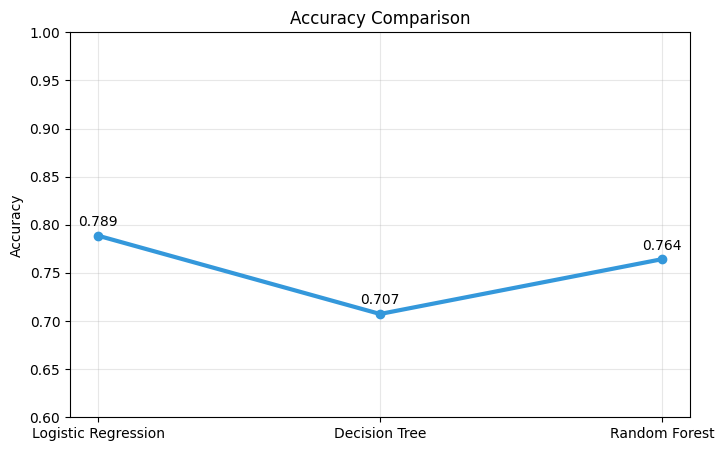

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    models,
    results["Accuracy"],
    marker='o',
    linewidth=3,
    color='#3498db'
)

for i, value in enumerate(results["Accuracy"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha='center'
    )

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.6,1)

plt.grid(alpha=0.3)

plt.show()



.
# Precision Comparison

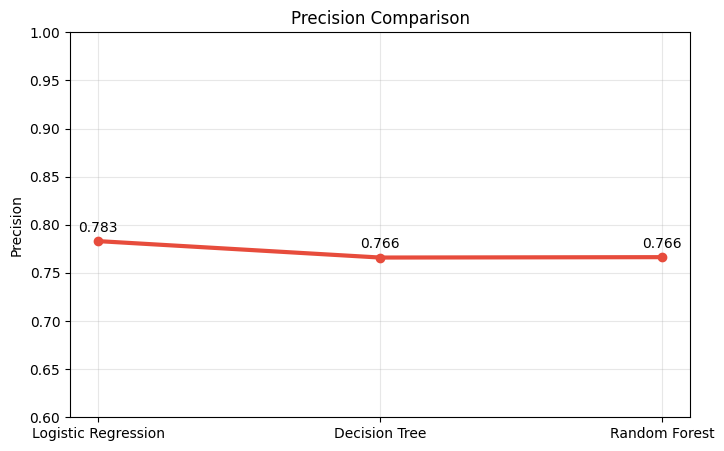

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    models,
    results["Precision"],
    marker='o',
    linewidth=3,
    color='#e74c3c'
)

for i, value in enumerate(results["Precision"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha='center'
    )

plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.ylim(0.6,1)

plt.grid(alpha=0.3)

plt.show()

.

# Recall Comparison

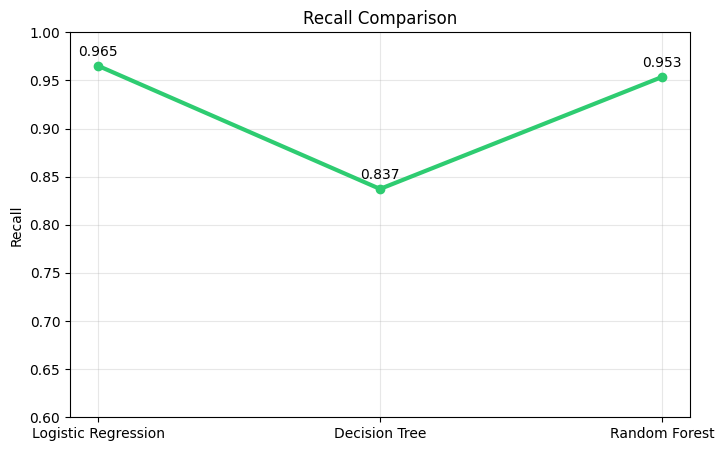

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    models,
    results["Recall"],
    marker='o',
    linewidth=3,
    color='#2ecc71'
)

for i, value in enumerate(results["Recall"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha='center'
    )

plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.ylim(0.6,1)

plt.grid(alpha=0.3)

plt.show()

.

# F1 Score Comparison

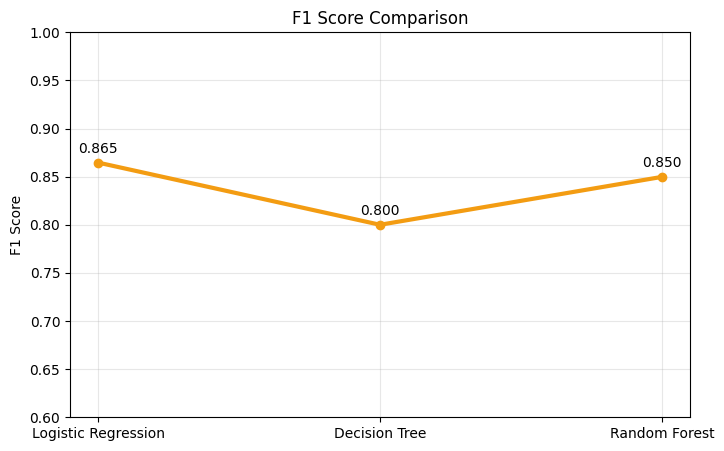

In [34]:
plt.figure(figsize=(8,5))

plt.plot(
    models,
    results["F1 Score"],
    marker='o',
    linewidth=3,
    color='#f39c12'
)

for i, value in enumerate(results["F1 Score"]):
    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha='center'
    )

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0.6,1)

plt.grid(alpha=0.3)

plt.show()

.

.
# Model Performance Comparison

In [35]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.788618,0.783019,0.965116,0.864583
1,Decision Tree,0.707317,0.765957,0.837209,0.800000
2,Random Forest,0.764228,0.766355,0.953488,0.849741


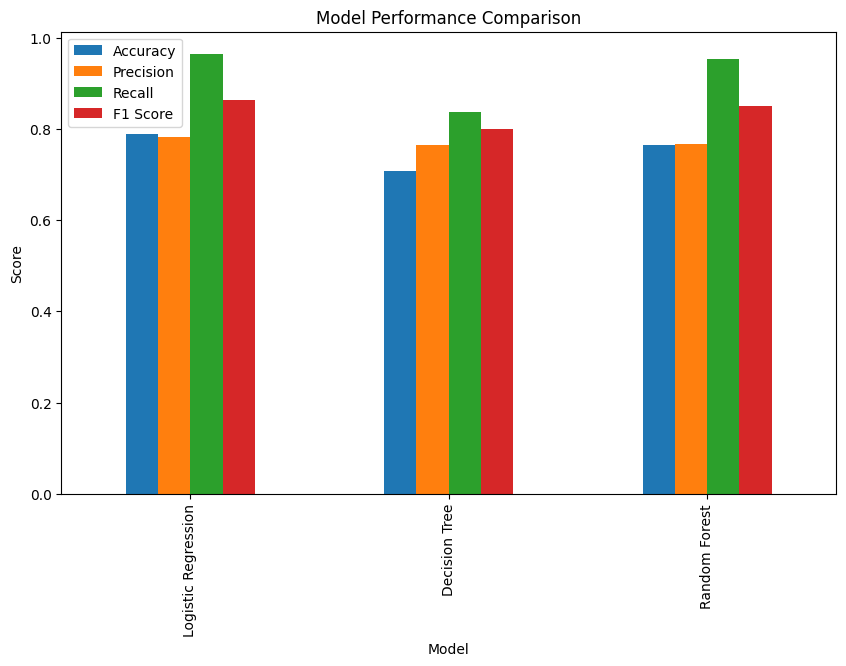

In [36]:
metrics_df = results.set_index("Model")

metrics_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.show()

## Modellerin Karşılaştırılması

Bu grafik Logistic Regression, Decision Tree ve Random Forest algoritmalarının doğruluk oranlarını karşılaştırmaktadır.

En yüksek doğruluğa sahip model proje kapsamında en başarılı model olarak değerlendirilmiştir.

.

.

.

.

## Cross Validation 

In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LogisticRegression(),
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.80487805 0.7804878  0.78861789 0.82113821 0.83606557]

Average Accuracy:
0.8062375049980008


## Cross Validation

Model performansının daha güvenilir şekilde ölçülebilmesi için 5 katlı Cross Validation uygulanmıştır.

Veri seti 5 parçaya ayrılmıştır.

Her seferinde:
- 4 parça eğitim
- 1 parça test

olarak kullanılmıştır.

Bu işlem 5 kez tekrar edilerek modelin genelleme başarısı ölçülmüştür.

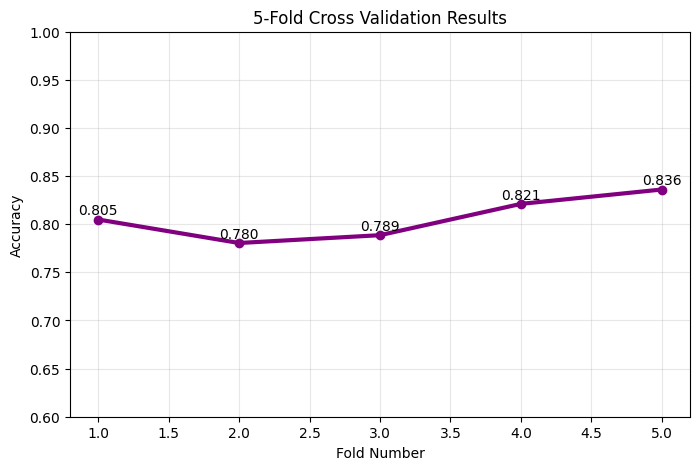

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    cv_scores,
    marker='o',
    linewidth=3,
    color='purple'
)

for i, score in enumerate(cv_scores):
    plt.text(
        i+1,
        score+0.005,
        f"{score:.3f}",
        ha='center'
    )

plt.title("5-Fold Cross Validation Results")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.ylim(0.6,1)

plt.grid(alpha=0.3)

plt.show()

In [39]:
fold_results = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "Accuracy": cv_scores
})

fold_results

,Fold,Accuracy
0,1,0.804878
1,2,0.780488
2,3,0.788618
3,4,0.821138
4,5,0.836066


## Cross Validation Sonuçları

5 katlı Cross Validation sonucunda model ortalama %80.62 doğruluk elde etmiştir.

Bu sonuç modelin farklı veri parçalarında benzer performans gösterdiğini ve genelleme yeteneğinin iyi olduğunu göstermektedir.

Cross Validation sonucu ile test doğruluğunun birbirine yakın olması modelin aşırı öğrenme (overfitting) yapmadığını göstermektedir.

.


# Confusion Matrix


In [40]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

cm

array([[14, 23],
       [ 3, 83]])

| Gerçek | Tahmin | Sayı |
| ------ | ------ | ---- |
| Red    | Red    | 18   |
| Red    | Onay   | 25   |
| Onay   | Red    | 1    |
| Onay   | Onay   | 79   |

.
.

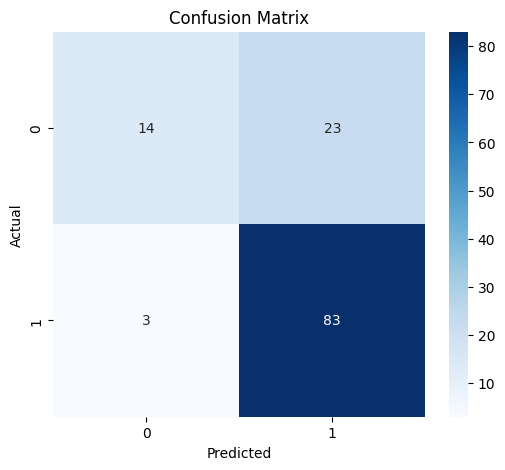

In [41]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Confusion Matrix

Confusion Matrix modeli daha detaylı değerlendirmek amacıyla oluşturulmuştur.

Bu matris:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

değerlerini göstermektedir.

Bu sayede modelin hangi sınıflarda hata yaptığı incelenebilmektedir.

.

.


.




## MODEL PERFORMANS ANALİZİ - ROC EĞRİSİ  & AUC

In [42]:
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]


.

.
## 1.Logistic Regression ROC Curve

In [43]:
from sklearn.metrics import roc_curve, auc

lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

lr_auc = auc(lr_fpr, lr_tpr)

print("Logistic Regression AUC:", lr_auc)

Logistic Regression AUC: 0.6847894406033941


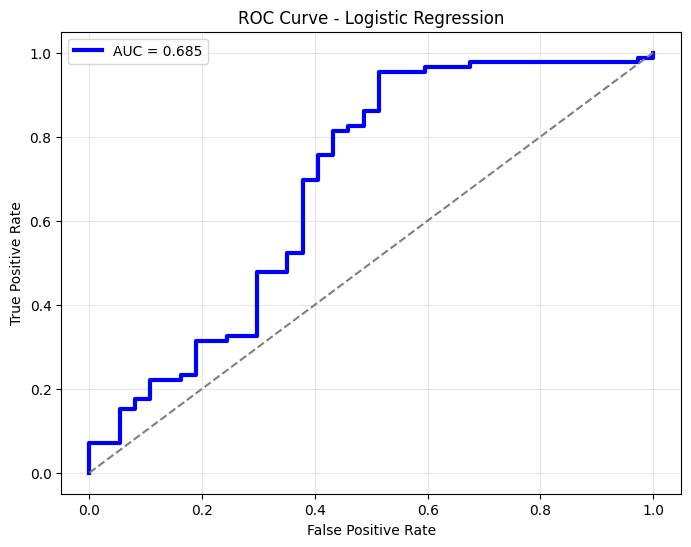

In [44]:
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=3,
    label=f"AUC = {lr_auc:.3f}",
    color="blue"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Logistic Regression ROC Curve

Bu grafik Logistic Regression modelinin kredi onayı ve kredi reddi sınıflarını ayırt etme başarısını göstermektedir.

AUC değeri model performansını özetlemektedir. AUC değerinin 1'e yaklaşması model başarısının arttığını göstermektedir.

.

.



## 2.Decision Tree ROC Curve

In [45]:
dt_prob = dt_model.predict_proba(X_test)[:,1]

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

dt_auc = auc(dt_fpr, dt_tpr)

print("Decision Tree AUC:", dt_auc)

Decision Tree AUC: 0.6213073538654934


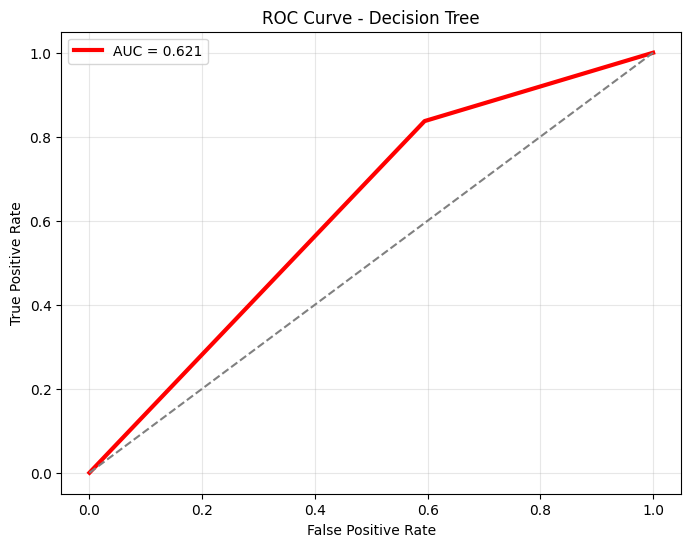

In [46]:
plt.figure(figsize=(8,6))

plt.plot(
    dt_fpr,
    dt_tpr,
    linewidth=3,
    label=f"AUC = {dt_auc:.3f}",
    color="red"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title("ROC Curve - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Decision Tree ROC Curve

Bu grafik Decision Tree modelinin sınıflandırma performansını göstermektedir.

Elde edilen AUC değeri modelin kredi onayı ve kredi reddi sınıflarını ayırt etme başarısını ifade etmektedir.

.

.

## 3.Random Forest ROC Curve

In [47]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

rf_auc = auc(rf_fpr, rf_tpr)

print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.7763984915147706


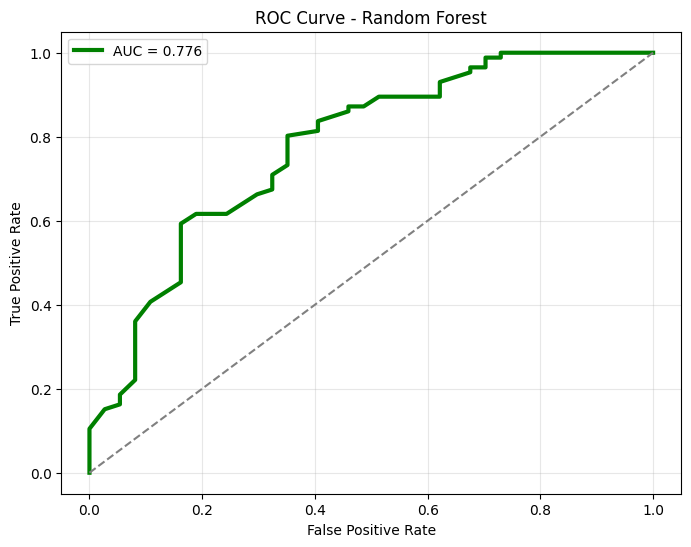

In [48]:
plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=3,
    label=f"AUC = {rf_auc:.3f}",
    color="green"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Random Forest ROC Curve

Bu grafik Random Forest modelinin ROC performansını göstermektedir.

AUC değeri modelin sınıfları ayırt etme başarısını ölçmektedir.

.

.

## ROC Curve Comparison

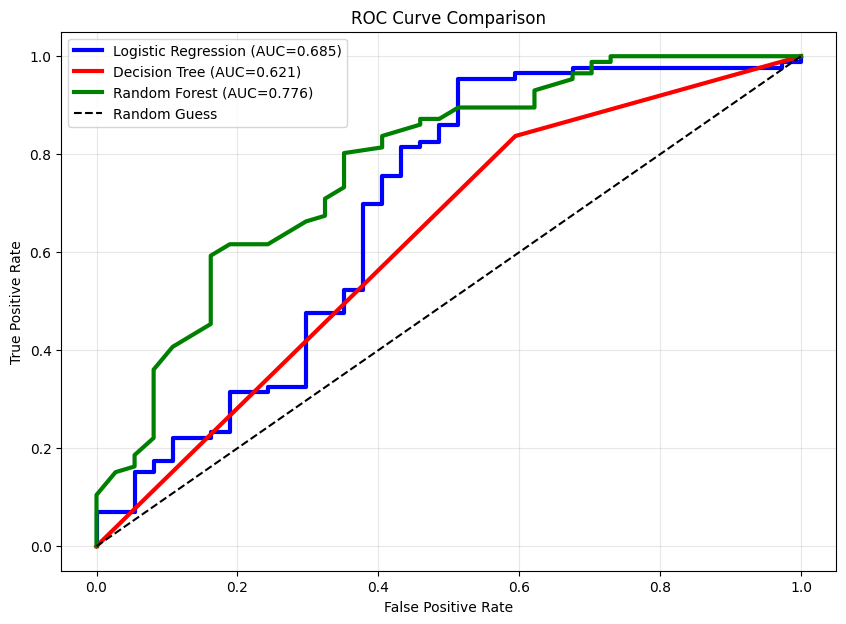

In [49]:
plt.figure(figsize=(10,7))

plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=3,
    label=f"Logistic Regression (AUC={lr_auc:.3f})",
    color="blue"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    linewidth=3,
    label=f"Decision Tree (AUC={dt_auc:.3f})",
    color="red"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=3,
    label=f"Random Forest (AUC={rf_auc:.3f})",
    color="green"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Random Guess"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [50]:
auc_results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "AUC":[
        lr_auc,
        dt_auc,
        rf_auc
    ]
})

auc_results

,Model,AUC
0,Logistic Regression,0.684789
1,Decision Tree,0.621307
2,Random Forest,0.776398


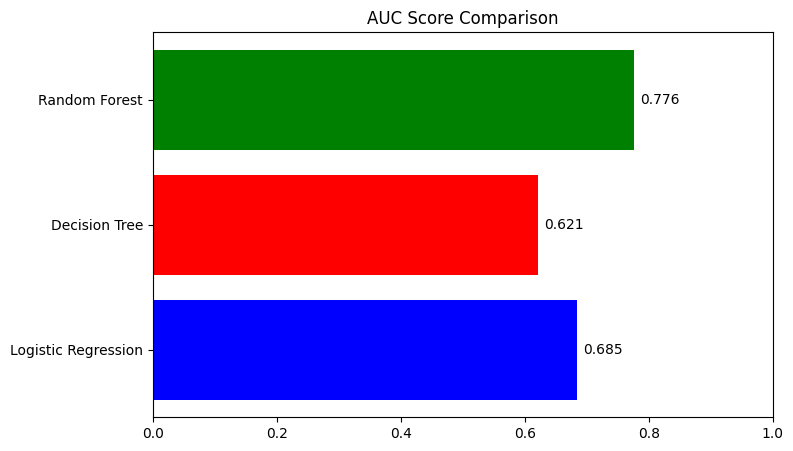

In [51]:
plt.figure(figsize=(8,5))

colors = ["blue","red","green"]

bars = plt.barh(
    auc_results["Model"],
    auc_results["AUC"],
    color=colors
)

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.01,
        bar.get_y()+bar.get_height()/2,
        f"{width:.3f}",
        va="center"
    )

plt.title("AUC Score Comparison")
plt.xlim(0,1)

plt.show()

# Yapay zeka 


In [52]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_[0]
})

feature_importance

,Feature,Coefficient
0,Gender,-0.035856
1,Married,0.171476
2,Dependents,0.070889
3,Education,-0.149249
4,Self_Employed,0.137658
5,ApplicantIncome,0.645003
6,CoapplicantIncome,1.186435
7,LoanAmount,-0.326333
8,Loan_Amount_Term,-0.017301
9,Credit_History,0.839867


.

.

## 3. Logistic Regression Explainable AI

In [53]:
feature_importance["Abs_Coefficient"] = abs(
    feature_importance["Coefficient"]
)

feature_importance = feature_importance.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Abs_Coefficient
6,CoapplicantIncome,1.186435,1.186435
9,Credit_History,0.839867,0.839867
5,ApplicantIncome,0.645003,0.645003
7,LoanAmount,-0.326333,0.326333
1,Married,0.171476,0.171476
3,Education,-0.149249,0.149249
4,Self_Employed,0.137658,0.137658
10,Property_Area,0.123907,0.123907
2,Dependents,0.070889,0.070889
0,Gender,-0.035856,0.035856


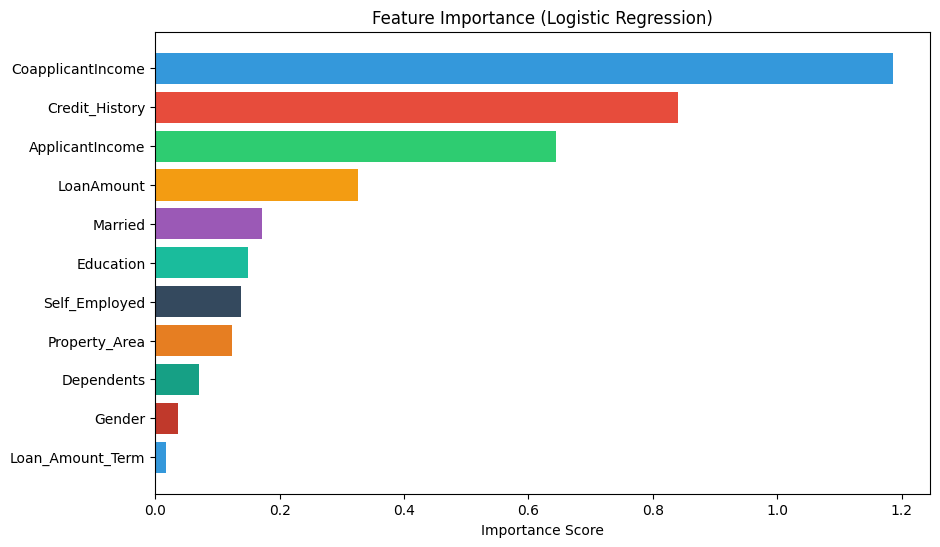

In [54]:
plt.figure(figsize=(10,6))

colors = [
    "#3498db",
    "#e74c3c",
    "#2ecc71",
    "#f39c12",
    "#9b59b6",
    "#1abc9c",
    "#34495e",
    "#e67e22",
    "#16a085",
    "#c0392b"
]

plt.barh(
    feature_importance["Feature"],
    feature_importance["Abs_Coefficient"],
    color=colors[:len(feature_importance)]
)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

.

## 1. Decision Tree Explainable AI

In [55]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

dt_importance

,Feature,Importance
5,ApplicantIncome,0.342833
7,LoanAmount,0.218450
9,Credit_History,0.151028
6,CoapplicantIncome,0.118482
2,Dependents,0.043412
8,Loan_Amount_Term,0.037415
10,Property_Area,0.028531
0,Gender,0.020092
4,Self_Employed,0.017182
3,Education,0.014125


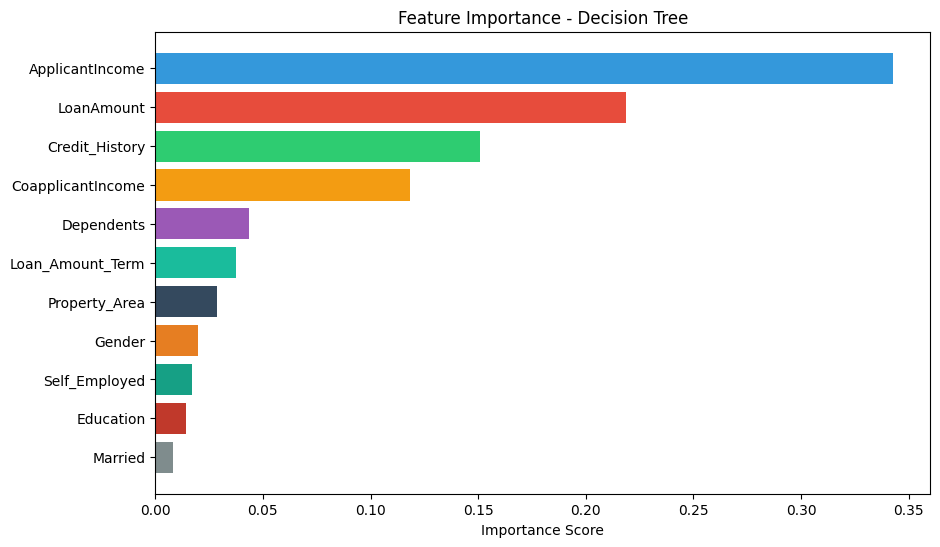

In [56]:
plt.figure(figsize=(10,6))

colors = [
    "#3498db","#e74c3c","#2ecc71","#f39c12",
    "#9b59b6","#1abc9c","#34495e","#e67e22",
    "#16a085","#c0392b","#7f8c8d"
]

plt.barh(
    dt_importance["Feature"],
    dt_importance["Importance"],
    color=colors[:len(dt_importance)]
)

plt.title("Feature Importance - Decision Tree")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

.

## 2. Random Forest Explainable AI

In [57]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
5,ApplicantIncome,0.245110
7,LoanAmount,0.221388
9,Credit_History,0.158262
6,CoapplicantIncome,0.124035
8,Loan_Amount_Term,0.061629
10,Property_Area,0.053083
2,Dependents,0.044294
1,Married,0.026716
0,Gender,0.023463
3,Education,0.021640


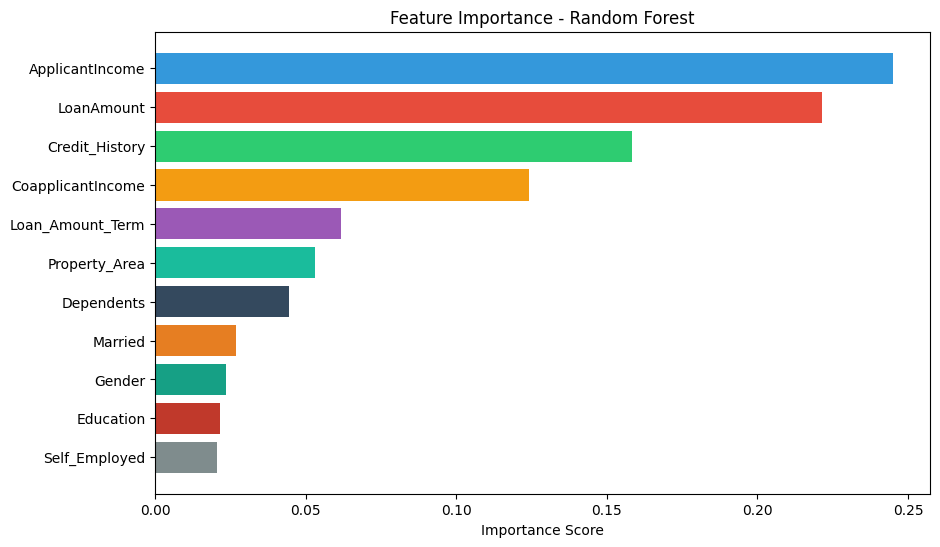

In [58]:
plt.figure(figsize=(10,6))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"],
    color=colors[:len(rf_importance)]
)

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

.

### Karşılaştırma Tablosu

In [59]:
comparison_importance = pd.DataFrame({
    "Feature": X.columns,
    "Logistic Regression": abs(lr_model.coef_[0]),
    "Decision Tree": dt_model.feature_importances_,
    "Random Forest": rf_model.feature_importances_
})

comparison_importance

,Feature,Logistic Regression,Decision Tree,Random Forest
0,Gender,0.035856,0.020092,0.023463
1,Married,0.171476,0.008452,0.026716
2,Dependents,0.070889,0.043412,0.044294
3,Education,0.149249,0.014125,0.021640
4,Self_Employed,0.137658,0.017182,0.020380
5,ApplicantIncome,0.645003,0.342833,0.245110
6,CoapplicantIncome,1.186435,0.118482,0.124035
7,LoanAmount,0.326333,0.218450,0.221388
8,Loan_Amount_Term,0.017301,0.037415,0.061629
9,Credit_History,0.839867,0.151028,0.158262


.

.

### Top 5 Özelliği Karşılaştırma

In [60]:
comparison_importance["Average"] = (
    comparison_importance["Logistic Regression"] +
    comparison_importance["Decision Tree"] +
    comparison_importance["Random Forest"]
) / 3

top_features = comparison_importance.sort_values(
    by="Average",
    ascending=False
).head(5)

top_features

,Feature,Logistic Regression,Decision Tree,Random Forest,Average
6,CoapplicantIncome,1.186435,0.118482,0.124035,0.476317
5,ApplicantIncome,0.645003,0.342833,0.245110,0.410982
9,Credit_History,0.839867,0.151028,0.158262,0.383052
7,LoanAmount,0.326333,0.218450,0.221388,0.255390
1,Married,0.171476,0.008452,0.026716,0.068881


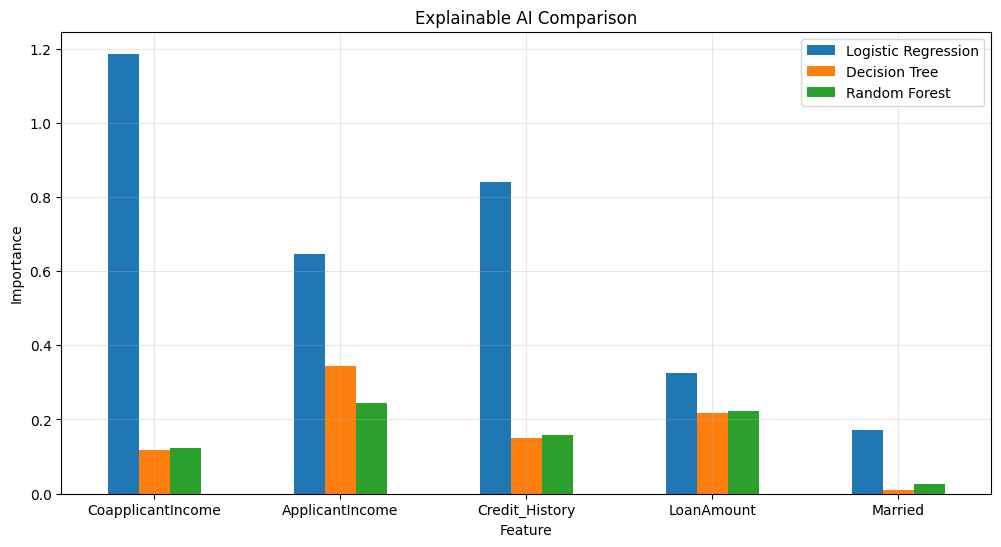

In [61]:
top_features_plot = top_features.set_index("Feature")

top_features_plot[
    [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Explainable AI Comparison")

plt.ylabel("Importance")

plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.show()

In [62]:
import joblib

joblib.dump(lr_model, "../models/logistic_regression_model.pkl")

joblib.dump(dt_model, "../models/decision_tree_model.pkl")

joblib.dump(rf_model, "../models/random_forest_model.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

print("All models saved successfully.")

All models saved successfully.
